In [31]:
import numpy as np
def KonGrad_Q(A,b,c,x0,tol,itmax):
    g = A@x0 - b
    p = -g
    x = x0
    history = [x]
    for i in range(itmax):
        q = A@p
        alpha = np.dot(g,g)/np.dot(p,q)
        x = x + alpha * p
        history.append(x)
        gk = g + alpha*q
        if np.linalg.norm(gk) < tol: 
            print("Dosazeno predepsane tolerance") 
            fmin = 0.5*x.T@A@x - b.T@x + c
            return x, fmin, i, np.array(history)
        beta = np.dot(gk,gk)/np.dot(g,g)
        p = -gk + beta*p
        g = gk
    print("Dosazeno maximalnho poctu iteraci")
    fmin = 0.5*x.T@A@x - b.T@x + c
    return x, fmin, i, np.array(history)

In [ ]:
x0 = np.array([0.33, 0.33, 0.34])
K = np.array([                  # Kovarianční matice rizika
    [0.045, 0.030, 0.035],
    [0.030, 0.160, 0.040],
    [0.035, 0.040, 0.060]
])
mu = np.array([0.233, 0.362, 0.242])
c = 10000
n = len(x0)
J = np.ones((n, n))   
o = np.ones(n)    
real_risk = np.dot(x0.T, np.dot(K, x0))
r_min = 0.25
A = 2 * (K + c * J + c * np.outer(mu, mu))
b = 2 * c * o + 2 * c * r_min * mu
x1, f1, i1, history1 = KonGrad_Q(A, b, c, x0, 0.01, 10)
print(f"Bod minima: {x1}")
print(f"Minimalni hodnota funkce: {f1}")
print(f"pocet iteraci: {i1+1}") # Protože indexování v cyklu for i in range(itmax) je od nuly
print("jednotlive iterace: ") 
print(f"{np.array(history1)}")
print(real_risk)

Dosazeno predepsane tolerance
Bod minima: [0.65200987 0.11553198 0.23245521]
Minimalni hodnota funkce: -624.9582140837629
pocet iteraci: 3
jednotlive iterace: 
[[0.33       0.33       0.34      ]
 [0.32785816 0.32667172 0.3377752 ]
 [0.45699262 0.10091351 0.44209057]
 [0.65200987 0.11553198 0.23245521]]
0.052624500000000005


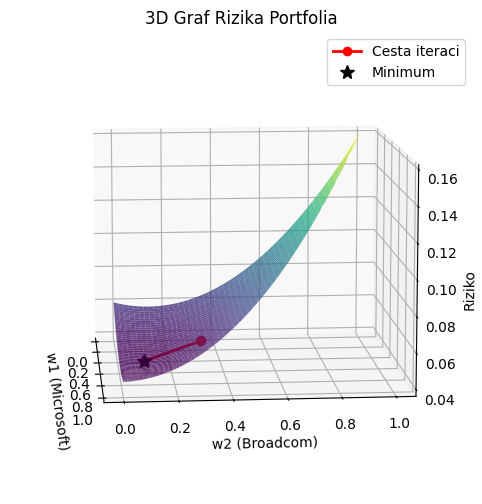

In [37]:
import numpy as np
import matplotlib.pyplot as plt

w1 = np.linspace(0, 1, 100)
w2 = np.linspace(0, 1, 100)
W1, W2 = np.meshgrid(w1, w2)
W3 = 1 - W1 - W2

Z = (K[0,0]*W1**2 + K[1,1]*W2**2 + K[2,2]*W3**2 + 
     2*K[0,1]*W1*W2 + 2*K[0,2]*W1*W3 + 2*K[1,2]*W2*W3)
Z[W1 + W2 > 1] = np.nan
w1_it = history1[:, 0] 
w2_it = history1[:, 1]
w3_it = history1[:, 2]
z_it = (0.070*w1_it**2 + 0.120*w2_it**2 + 0.030*w3_it**2 + 
        2*0.040*w1_it*w2_it + 2*0.025*w1_it*w3_it + 2*0.035*w2_it*w3_it)

fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(W1, W2, Z, cmap='viridis', alpha=0.8)
ax.plot(w1_it, w2_it, z_it, 'r-o', linewidth=2, label='Cesta iteraci')
ax.plot(w1_it[-1:], w2_it[-1:], z_it[-1:], 'k*', markersize=10, label='Minimum')
ax.view_init(elev=10, azim= -5)
ax.set_title("3D Graf Rizika Portfolia")
ax.set_xlabel("w1 (Microsoft)")
ax.set_ylabel("w2 (Broadcom)")
ax.set_zlabel("Riziko")
ax.legend()

plt.show()